# TP3 — Modelos Generativos Profundos: VAE, β-VAE y GAN
## Solucionario Docente — Aprendizaje Profundo — UNSAM

> Implementación completa, explicaciones extendidas, análisis crítico,
> ablation study, visualizaciones pedagógicas y respuestas al informe.

| Sección | Contenido |
|---|---|
| 0 | Setup reproducible |
| 1 | Dataset y exploración visual |
| 2 | Teoría extendida: ELBO, KL cerrada, reparametrización |
| 3 | Configuración del modelo |
| 4 | **Implementación completa del ConvVAE** |
| 5 | Checkpoint automático |
| 6 | Entrenamiento con KL annealing |
| 7 | Reconstrucción, generación e interpolación |
| 8 | Visualización del espacio latente (PCA + t-SNE) |
| 9 | Linear probe: ¿qué tan útil es el espacio latente? |
| 10 | **Ablation study: β, latent_dim, capacidad** |
| 11 | Análisis del posterior collapse |
| 12 | Extensión: caras (Olivetti Faces) |
| 13 | Extensión: GAN mínimo y comparación |
| 14 | **Informe final completo con respuestas modelo** |
| 15 | Preguntas de defensa con respuestas esperadas |


## 0. Setup reproducible

Fijamos semillas en todas las librerías relevantes para reproducibilidad entre corridas.
La detección de device es portable: funciona en Colab (CUDA), Apple Silicon (MPS) o CPU.

**¿Por qué fijamos la semilla?**  
El VAE usa muestreo estocástico (reparametrización). Sin semilla fija, cada corrida puede
inicializar pesos distintos y producir resultados levemente diferentes.


In [1]:
import os, math, random, warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
warnings.filterwarnings('ignore', category=UserWarning)

try:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False
    print('[!] sklearn no disponible; PCA/t-SNE/linear probe se omitiran.')

# -- Semillas -----------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -- Device -------------------------------------------------------------------
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
    torch.set_num_threads(4)

print(f'Device      : {device}')
print(f'PyTorch     : {torch.__version__}')
print(f'Torchvision : {torchvision.__version__}')
print(f'sklearn     : {SKLEARN_AVAILABLE}')


Device      : cuda
PyTorch     : 2.11.0+cu128
Torchvision : 0.26.0+cu128
sklearn     : True


## 1. Dataset y exploración visual

Usamos **FashionMNIST** por defecto: 10 clases de ropa, `1x28x28` pixeles en escala de grises.
Cambiar `DATASET_NAME = 'MNIST'` para un entrenamiento mas rapido.

**Por que FashionMNIST y no MNIST?**  
Los digitos de MNIST son tan simples que casi cualquier modelo los reconstruye bien.
FashionMNIST tiene mas variacion intra-clase y el trade-off beta-VAE es mas visible.


In [2]:
DATASET_NAME  = 'FashionMNIST'   # 'MNIST' o 'FashionMNIST'
DATA_ROOT     = './data'
FAST_DEV_RUN  = False

transform = transforms.Compose([transforms.ToTensor()])

def get_dataset(name, train):
    cls = {'MNIST': datasets.MNIST, 'FashionMNIST': datasets.FashionMNIST}[name]
    return cls(DATA_ROOT, train=train, download=True, transform=transform)

train_ds = get_dataset(DATASET_NAME, train=True)
val_ds   = get_dataset(DATASET_NAME, train=False)

if FAST_DEV_RUN:
    train_ds = Subset(train_ds, range(8000))
    val_ds   = Subset(val_ds,   range(2000))

CLASSES = (['T-shirt/top','Trouser','Pullover','Dress','Coat',
            'Sandal','Shirt','Sneaker','Bag','Ankle boot']
           if DATASET_NAME == 'FashionMNIST'
           else [str(i) for i in range(10)])

print(f'Dataset : {DATASET_NAME}')
print(f'Train   : {len(train_ds):,} muestras')
print(f'Val     : {len(val_ds):,} muestras')
print(f'Clases  : {CLASSES}')


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.26MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.2MB/s]

Dataset : FashionMNIST
Train   : 60,000 muestras
Val     : 10,000 muestras
Clases  : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


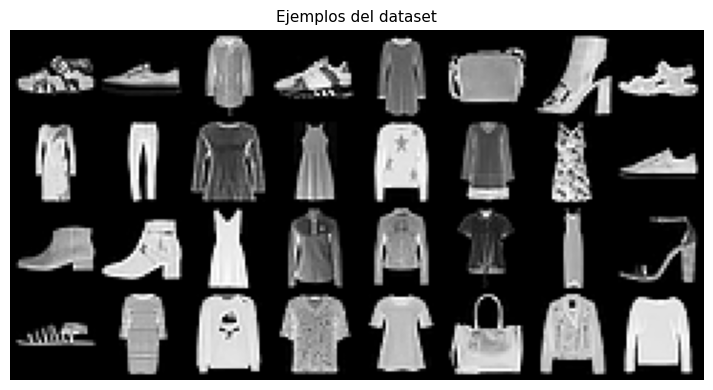

Batch shape: torch.Size([32, 1, 28, 28]) | Rango: 0.0 - 1.0


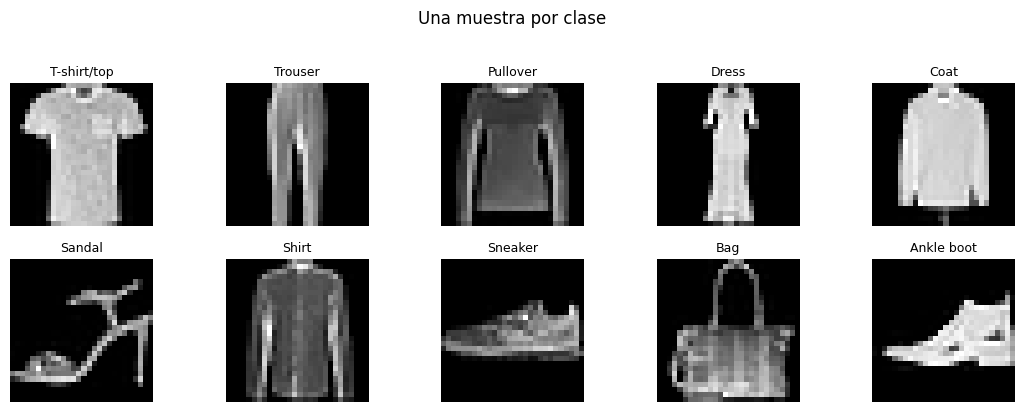

In [3]:
# -- Helper de visualizacion --------------------------------------------------
def show_image_grid(x, title='', nrow=8, figsize=(10,4)):
    x = x.detach().cpu().clamp(0,1)
    grid = make_grid(x, nrow=nrow, padding=2)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
    ax.axis('off')
    if title: ax.set_title(title, fontsize=11)
    plt.tight_layout(); plt.show()

# Batch de ejemplo
_loader_tmp = DataLoader(train_ds, batch_size=32, shuffle=True)
xb, yb = next(iter(_loader_tmp))
show_image_grid(xb, title='Ejemplos del dataset')
print('Batch shape:', xb.shape, '| Rango:', xb.min().item(), '-', xb.max().item())

# Una muestra por clase
fig, axes = plt.subplots(2, 5, figsize=(11,4))
shown = {}
for x, y in DataLoader(train_ds, batch_size=256, shuffle=True):
    for img, label in zip(x, y):
        label = int(label)
        if label not in shown: shown[label] = img
        if len(shown) == 10: break
    if len(shown) == 10: break
for i, ax in enumerate(axes.flat):
    ax.imshow(shown[i].squeeze(), cmap='gray')
    ax.set_title(CLASSES[i], fontsize=9); ax.axis('off')
plt.suptitle('Una muestra por clase', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## 2. Teoria extendida: del Autoencoder al VAE

### 2.1 Autoencoder determinístico

Un AE aprende una compresion:
$$z = f_\phi(x), \qquad \hat{x} = g_\theta(z)$$
La loss es solo reconstruccion. El problema: el espacio latente no tiene estructura garantizada.
Muestrear aleatoriamente produce basura porque las zonas intermedias del espacio no tienen significado.

### 2.2 El VAE como modelo generativo probabilistico

El VAE plantea el problema en terminos probabilisticos:
- **Prior:** $p(z) = \mathcal{N}(0, I)$
- **Likelihood (decoder):** $p_\theta(x \mid z)$
- **Posterior aproximado (encoder):** $q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \operatorname{diag}(\sigma^2_\phi(x)))$

Queremos maximizar la evidencia $\log p_\theta(x)$, que es intratable.
En cambio maximizamos la **ELBO** (Evidence Lower BOund):

$$\log p_\theta(x) \geq \underbrace{\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]}_{\text{reconstruccion}} - \underbrace{D_{KL}(q_\phi(z \mid x) \;\|\; p(z))}_{\text{regularizacion}}$$

En practica minimizamos:
$$\mathcal{L}(x) = \underbrace{\mathcal{L}_{\text{rec}}(x, \hat{x})}_{\text{BCE o MSE}} + \beta \underbrace{D_{KL}(q_\phi(z \mid x) \;\|\; p(z))}_{\text{KL cerrada}}$$

### 2.3 KL cerrada para gaussianas diagonales

$$D_{KL}(\mathcal{N}(\mu, \sigma^2) \;\|\; \mathcal{N}(0, I)) = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**Si $\mu=0$ y $\sigma=1$**: la KL es exactamente 0 (el posterior coincide con el prior).

### 2.4 Truco de reparametrizacion

El muestreo $z \sim q_\phi(z \mid x)$ no es diferenciable respecto de $\phi$. La solucion:

$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

Ahora el gradiente fluye a traves de $\mu$ y $\sigma$. El unico nodo estocastico es $\epsilon$, sin parametros.

**Por que `logvar` y no $\sigma$?**  
Porque la red puede predecir cualquier valor real. $\sigma^2 = e^{\text{logvar}}$ es siempre positivo, sin restricciones.

### 2.5 El rol de beta (beta-VAE)

| beta | Efecto |
|---|---|
| beta = 0 | Autoencoder puro (sin regularizacion KL) |
| beta = 1 | VAE estandar (Kingma & Welling 2013) |
| beta < 1 | Mas enfasis en reconstruccion; espacio menos regular |
| beta > 1 | Mas regularizacion; reconstrucciones peores; posterior collapse posible |

### 2.6 Posterior collapse

Ocurre cuando $q_\phi(z|x) \approx p(z)$: el encoder colapsa al prior, la KL cae a 0
y el decoder ignora el latente.  
**Deteccion:** KL por dimension < 0.1 en muchas dimensiones.  
**Mitigaciones:** KL annealing, free bits, reducir capacidad del decoder.


## 3. Configuracion del modelo

Usamos un `dataclass` para que todos los experimentos sean reproducibles y comparables.
Cada variante del ablation study es una instancia diferente de `VAEConfig`.


In [4]:
@dataclass
class VAEConfig:
    # Arquitectura
    input_channels:   int            = 1
    image_size:       int            = 28
    latent_dim:       int            = 16
    hidden_channels:  Tuple[int,int] = (32, 64)
    # beta-VAE
    beta:             float          = 1.0
    free_bits:        float          = 0.0  # KL minima por dimension
    # Entrenamiento
    batch_size:       int            = 128
    lr:               float          = 1e-3
    weight_decay:     float          = 1e-5
    epochs:           int            = 15
    kl_anneal_epochs: int            = 5    # epocas para subir beta de 0 a beta
    num_workers:      int            = 2

base_cfg = VAEConfig()
print(base_cfg)


VAEConfig(input_channels=1, image_size=28, latent_dim=16, hidden_channels=(32, 64), beta=1.0, free_bits=0.0, batch_size=128, lr=0.001, weight_decay=1e-05, epochs=15, kl_anneal_epochs=5, num_workers=2)


## 4. Implementacion completa del ConvVAE

### Arquitectura

```
ENCODER
  Conv2d(1->32, k=4, s=2, p=1) + BN + LeakyReLU(0.2)  ->  (32, 14, 14)
  Conv2d(32->64, k=4, s=2, p=1) + BN + LeakyReLU(0.2) ->  (64,  7,  7)
  Flatten                                               ->  3136
  fc_mu:    Linear(3136 -> latent_dim)
  fc_logvar: Linear(3136 -> latent_dim)

REPARAMETRIZACION
  z = mu + exp(0.5 * logvar) * eps,   eps ~ N(0,I)

DECODER
  fc_decode: Linear(latent_dim -> 3136)
  Reshape                             ->  (64, 7, 7)
  ConvTranspose2d(64->32, k=4, s=2, p=1) + BN + ReLU  ->  (32, 14, 14)
  ConvTranspose2d(32->1, k=4, s=2, p=1) + Sigmoid      ->  (1, 28, 28)
```

**Por que Conv con stride=2 y no MaxPool?**  
MaxPool descarta informacion. Conv con stride aprende como submuestrear.
En el decoder, ConvTranspose2d aprende como interpolar (al reves del encoder).

**Por que BatchNorm + LeakyReLU en el encoder?**  
BatchNorm estabiliza el entrenamiento. LeakyReLU(0.2) evita el dying-ReLU
que es critico con BatchNorm.


In [5]:
class ConvVAE(nn.Module):
    def __init__(self, cfg: VAEConfig):
        super().__init__()
        self.cfg = cfg
        c1, c2 = cfg.hidden_channels

        # -- Encoder convolucional ------------------------------------------
        # Cada Conv2d con stride=2 divide alto y ancho a la mitad.
        # 28x28 -> 14x14 -> 7x7
        self.encoder = nn.Sequential(
            nn.Conv2d(cfg.input_channels, c1, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(c1, c2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c2),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Calculamos la dimension del feature map aplanado dinamicamente
        # para que el modelo funcione con cualquier image_size.
        with torch.no_grad():
            dummy = torch.zeros(1, cfg.input_channels, cfg.image_size, cfg.image_size)
            h = self.encoder(dummy)
            self.enc_shape    = h.shape[1:]  # (c2, H', W')
            self.enc_flat_dim = int(np.prod(self.enc_shape))

        # -- Cabezas de la distribucion posterior ---------------------------
        self.fc_mu     = nn.Linear(self.enc_flat_dim, cfg.latent_dim)
        self.fc_logvar = nn.Linear(self.enc_flat_dim, cfg.latent_dim)

        # -- Proyeccion latente -> feature map ------------------------------
        self.fc_decode = nn.Linear(cfg.latent_dim, self.enc_flat_dim)

        # -- Decoder transpuesto --------------------------------------------
        # Invierte las operaciones del encoder.
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(c2, c1, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(c1, cfg.input_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),  # imágenes en [0,1]
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)  # aplanar
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """
        Truco de reparametrizacion: z = mu + std * eps, eps ~ N(0,I).

        Por que exp(0.5 * logvar) y no exp(logvar):
            logvar = log(sigma^2)
            exp(0.5 * logvar) = exp(log(sigma)) = sigma

        Por que randn_like y no randn:
            randn_like genera un tensor del mismo shape Y DEVICE que std,
            sin necesidad de especificar device manualmente.

        La aleatoriedad esta solo en eps; el gradiente fluye
        normalmente a traves de mu y std hacia phi.
        """
        std = torch.exp(0.5 * logvar)  # sigma > 0 siempre
        eps = torch.randn_like(std)     # eps ~ N(0,I), mismo device
        return mu + std * eps

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), *self.enc_shape)
        return self.decoder(h)

    def forward(self, x):
        """
        x -> (recon_x, mu, logvar, z)

        Retornamos los 4 valores para:
        - calcular la loss (recon_x, mu, logvar)
        - analisis del espacio latente (z, mu)
        """
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        recon_x    = self.decode(z)
        return recon_x, mu, logvar, z


# -- Verificacion de shapes --------------------------------------------------
_cfg  = VAEConfig(latent_dim=16)
_m    = ConvVAE(_cfg)
_x    = torch.randn(4, 1, 28, 28)
_r, _mu, _lv, _z = _m(_x)
print('Verificacion de shapes:')
print(f'  entrada   : {_x.shape}')
print(f'  recon     : {_r.shape}')
print(f'  mu        : {_mu.shape}')
print(f'  logvar    : {_lv.shape}')
print(f'  z         : {_z.shape}')
print(f'  enc_shape : {_m.enc_shape}')
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'  parametros: {n_params:,}')
del _cfg, _m, _x, _r, _mu, _lv, _z


Verificacion de shapes:
  entrada   : torch.Size([4, 1, 28, 28])
  recon     : torch.Size([4, 1, 28, 28])
  mu        : torch.Size([4, 16])
  logvar    : torch.Size([4, 16])
  z         : torch.Size([4, 16])
  enc_shape : torch.Size([64, 7, 7])
  parametros: 220,641


### 4.2 Funcion de perdida VAE

La loss tiene dos terminos:

**1. Reconstruccion (BCE):** mide la fidelidad del decoder.
Usamos `binary_cross_entropy` con `reduction='sum'` dividido por el batch,
para que la magnitud sea comparable entre batches de diferente tamaño.

Por que suma por imagen y no por pixel? Porque si promediamos por pixel,
la KL se volveria comparativamente enorme y habria que escalar beta.
La convencion en la literatura (Kingma & Welling) es sumar por imagen.

**2. KL divergence (forma cerrada):** regulariza el espacio latente.

**Free bits:** si `free_bits > 0`, clampamos la KL minima por dimension.
Esto evita que el modelo descarte dimensiones utiles sin haber aprendido nada.


In [6]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0, free_bits=0.0):
    """
    Loss VAE = Reconstruccion + beta * KL

    Args:
        recon_x  : salida del decoder, (B,C,H,W) en [0,1]
        x        : imagen original,    (B,C,H,W) en [0,1]
        mu       : media del posterior, (B, latent_dim)
        logvar   : log-varianza,        (B, latent_dim)
        beta     : peso de la KL (1.0 = VAE estandar)
        free_bits: KL minima por dimension (bits libres)

    Returns:
        dict con keys: 'loss', 'recon', 'kl'
    """
    B = x.size(0)

    # -- Reconstruccion: BCE sumada por pixel, promediada por imagen ----------
    # reduction='sum' suma todos los pixeles de todo el batch.
    # Dividir por B da la reconstruccion promedio por imagen.
    # NO usar reduction='mean': promediar por pixel hace que la KL parezca
    # proporcionalmente enorme vs la reconstruccion.
    recon = F.binary_cross_entropy(
        recon_x.view(B, -1),
        x.view(B, -1),
        reduction='sum'
    ) / B

    # -- KL divergencia (forma cerrada) ----------------------------------------
    # D_KL(N(mu,sigma^2) || N(0,I))
    #   = -0.5 * sum_j (1 + log(sigma_j^2) - mu_j^2 - sigma_j^2)
    #   = -0.5 * sum_j (1 + logvar_j       - mu_j^2 - exp(logvar_j))
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # (B, latent_dim)

    # Free bits: cada dimension aporta al menos free_bits de KL
    # antes de contar. Previene que el modelo descarte dimensiones.
    if free_bits > 0.0:
        kl_per_dim = kl_per_dim.clamp(min=free_bits)

    # Sumar sobre dimensiones latentes, promediar sobre el batch
    kl = kl_per_dim.sum(dim=1).mean()  # escalar

    loss = recon + beta * kl

    return {'loss': loss, 'recon': recon, 'kl': kl}


## 5. Checkpoint automatico

Valida la implementacion antes del entrenamiento. Errores comunes que detecta:
- Shapes incorrectas en recon, mu, logvar, z
- NaN o Inf en cualquier tensor
- Decoder que produce valores fuera de [0,1]
- KL(N(0,I) || N(0,I)) != 0 (error en la formula de KL)
- Reparametrizacion inactiva (z == mu siempre)


In [7]:
def run_checkpoint():
    print('-- Checkpoint 1: VAE core ------------------------------------')
    cfg   = VAEConfig(batch_size=16, latent_dim=8)
    model = ConvVAE(cfg).to(device)
    x     = torch.randn(16, 1, 28, 28).to(device)

    recon, mu, logvar, z = model(x)

    # Shapes correctas
    assert recon.shape  == x.shape,               f'recon shape: {recon.shape}'
    assert mu.shape     == (16, cfg.latent_dim),   f'mu shape: {mu.shape}'
    assert logvar.shape == (16, cfg.latent_dim),   f'logvar shape: {logvar.shape}'
    assert z.shape      == (16, cfg.latent_dim),   f'z shape: {z.shape}'
    print('  [OK] Shapes del forward correctas')

    # Sin NaN/Inf
    for name, t in [('recon',recon),('mu',mu),('logvar',logvar),('z',z)]:
        assert torch.isfinite(t).all(), f'{name} contiene NaN o Inf'
    print('  [OK] Sin NaN/Inf')

    # Output del decoder en [0,1] (Sigmoid)
    assert recon.min() >= 0 and recon.max() <= 1, 'recon fuera de [0,1]'
    print('  [OK] recon en [0,1]')

    # Loss funciona y tiene las keys correctas
    ld = vae_loss(recon, x.clamp(0,1), mu, logvar, beta=1.0)
    for k in ['loss', 'recon', 'kl']:
        assert k in ld,               f"Falta key '{k}' en loss_dict"
        assert torch.isfinite(ld[k]), f'{k} no es finita: {ld[k]}'
    print(f"  [OK] Loss -> recon={ld['recon']:.2f}  kl={ld['kl']:.2f}")

    # Propiedad clave: KL(N(0,I) || N(0,I)) = 0
    mu0      = torch.zeros(4, cfg.latent_dim, device=device)
    logvar0  = torch.zeros(4, cfg.latent_dim, device=device)
    dummy    = torch.zeros(4, 1, 28, 28, device=device)
    kl0 = vae_loss(dummy, dummy, mu0, logvar0)['kl']
    assert torch.allclose(kl0, torch.tensor(0.0, device=device), atol=1e-5), \
        f'KL(N(0,I)||N(0,I)) deberia ser 0, dio {kl0.item():.6f}'
    print('  [OK] KL(N(0,I) || N(0,I)) = 0')

    # Reparametrizacion activa
    assert not torch.allclose(z, mu), 'z == mu: reparameterize puede no funcionar'
    print('  [OK] z != mu (reparametrizacion activa)')

    print('[CHECKPOINT PASADO]')

run_checkpoint()


-- Checkpoint 1: VAE core ------------------------------------
  [OK] Shapes del forward correctas
  [OK] Sin NaN/Inf
  [OK] recon en [0,1]
  [OK] Loss -> recon=596.23  kl=1.05
  [OK] KL(N(0,I) || N(0,I)) = 0
  [OK] z != mu (reparametrizacion activa)
[CHECKPOINT PASADO]


## 6. Entrenamiento con KL annealing

### KL Annealing

Durante las primeras epocas, el modelo no puede reconstruir bien todavia.
Si la KL pesa demasiado desde el inicio, el encoder colapsa al prior antes
de aprender una representacion util.

**Solucion:** empezar con `beta_eff = 0` y subirlo linealmente:
```
beta_eff(epoch) = beta * min(1, (epoch+1) / kl_anneal_epochs)
```

### Gradient clipping

`clip_grad_norm_(max_norm=5.0)` evita explosiones de gradiente,
especialmente en los primeros pasos cuando la loss puede ser grande.


In [8]:
def make_loaders(cfg):
    kw = dict(num_workers=(cfg.num_workers if device != 'cpu' else 0),
              pin_memory=(device == 'cuda'))
    return (
        DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  **kw),
        DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, **kw)
    )


def beta_schedule(epoch, cfg):
    if cfg.kl_anneal_epochs <= 0:
        return cfg.beta
    return cfg.beta * min(1.0, (epoch + 1) / cfg.kl_anneal_epochs)


def run_epoch(model, loader, optimizer=None, cfg=None, epoch=0):
    is_train  = optimizer is not None
    beta_eff  = beta_schedule(epoch, cfg) if cfg else 1.0
    free_bits = cfg.free_bits if cfg else 0.0

    model.train(is_train)
    running = {'loss': 0.0, 'recon': 0.0, 'kl': 0.0}
    n = 0

    with torch.set_grad_enabled(is_train):
        for x, _ in loader:
            x = x.to(device)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
            recon, mu, logvar, z = model(x)
            ld   = vae_loss(recon, x, mu, logvar, beta=beta_eff, free_bits=free_bits)
            loss = ld['loss']
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            bs = x.size(0)
            for k in running:
                running[k] += float(ld[k].detach().cpu()) * bs
            n += bs

    return {k: v / n for k, v in running.items()} | {'beta_eff': beta_eff}


def train_vae(cfg, verbose=True, tag=''):
    torch.manual_seed(SEED)
    train_loader, val_loader = make_loaders(cfg)
    model     = ConvVAE(cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=cfg.lr, weight_decay=cfg.weight_decay)
    history   = []
    n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if verbose:
        label = tag or f'beta={cfg.beta} dim={cfg.latent_dim}'
        print(f'--- Entrenando [{label}]  params={n_params:,}  epochs={cfg.epochs} ---')

    for epoch in range(cfg.epochs):
        tr = run_epoch(model, train_loader, optimizer=optimizer, cfg=cfg, epoch=epoch)
        with torch.no_grad():
            va = run_epoch(model, val_loader, cfg=cfg, epoch=epoch)
        row = {'epoch': epoch+1,
               **{f'train_{k}': v for k, v in tr.items()},
               **{f'val_{k}':   v for k, v in va.items()}}
        history.append(row)
        if verbose:
            print(f"  ep {epoch+1:02d}/{cfg.epochs}  "
                  f"beta_eff={tr['beta_eff']:.2f}  "
                  f"train loss={tr['loss']:.2f} "
                  f"(rec={tr['recon']:.2f} kl={tr['kl']:.2f})  "
                  f"val loss={va['loss']:.2f} "
                  f"(rec={va['recon']:.2f} kl={va['kl']:.2f})")

    return model, history


In [9]:
# -- Entrenamiento baseline --------------------------------------------------
# CPU: ~4 epocas son suficientes para ver el comportamiento.
# GPU Colab T4: 15 epocas toman ~5 minutos con FashionMNIST.

base_cfg = VAEConfig(
    latent_dim       = 16,
    beta             = 1.0,
    batch_size       = 128,
    lr               = 1e-3,
    epochs           = 15 if device != 'cpu' else 5,
    kl_anneal_epochs = 5,
)

vae_baseline, history_baseline = train_vae(base_cfg, tag='baseline beta=1 dim=16')


--- Entrenando [baseline beta=1 dim=16]  params=220,641  epochs=15 ---
  ep 01/15  beta_eff=0.20  train loss=256.91 (rec=249.44 kl=37.35)  val loss=237.40 (rec=230.02 kl=36.90)
  ep 02/15  beta_eff=0.40  train loss=238.87 (rec=227.03 kl=29.62)  val loss=237.98 (rec=226.40 kl=28.95)
  ep 03/15  beta_eff=0.60  train loss=241.24 (rec=226.49 kl=24.57)  val loss=242.03 (rec=227.60 kl=24.06)
  ep 04/15  beta_eff=0.80  train loss=243.83 (rec=226.98 kl=21.06)  val loss=244.59 (rec=227.82 kl=20.95)
  ep 05/15  beta_eff=1.00  train loss=246.32 (rec=227.66 kl=18.66)  val loss=247.13 (rec=227.87 kl=19.26)
  ep 06/15  beta_eff=1.00  train loss=245.14 (rec=226.94 kl=18.20)  val loss=246.33 (rec=228.12 kl=18.21)
  ep 07/15  beta_eff=1.00  train loss=244.29 (rec=226.32 kl=17.97)  val loss=246.13 (rec=227.77 kl=18.36)
  ep 08/15  beta_eff=1.00  train loss=243.69 (rec=225.87 kl=17.82)  val loss=244.99 (rec=227.24 kl=17.75)
  ep 09/15  beta_eff=1.00  train loss=243.20 (rec=225.44 kl=17.76)  val loss=244.

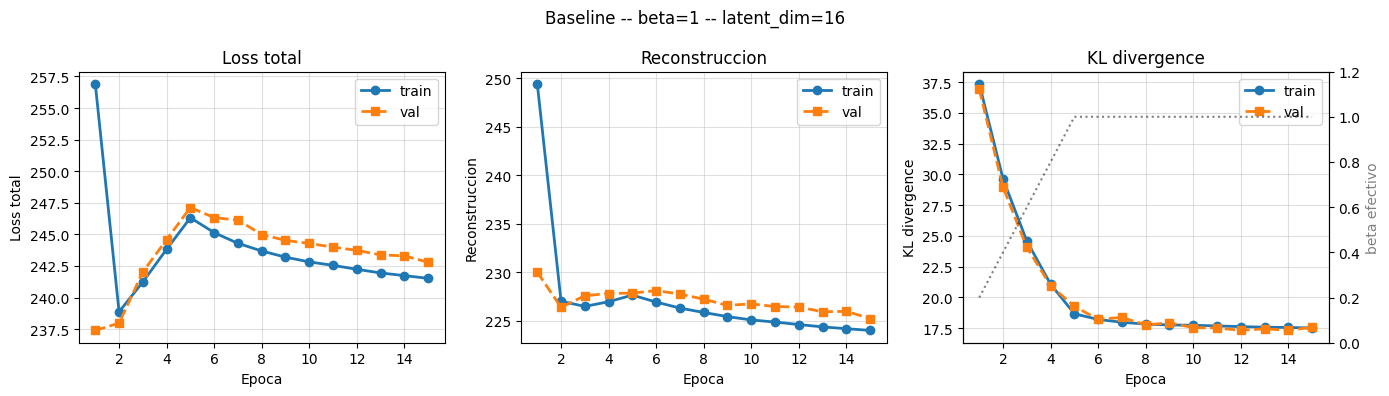

In [10]:
# -- Curvas de entrenamiento -------------------------------------------------
# Una buena curva muestra:
# - Train y val loss que convergen sin brecha grande (no hay overfitting severo).
# - KL sube gradualmente gracias al annealing.
# - Reconstruccion baja monotonamente.

def plot_history(history, title='Curvas VAE'):
    epochs = [h['epoch'] for h in history]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (y1k, y2k, ylabel, sub) in zip(axes, [
        ('train_loss',  'val_loss',  'Loss total',       'Loss total'),
        ('train_recon', 'val_recon', 'Reconstruccion',   'Reconstruccion'),
        ('train_kl',    'val_kl',   'KL divergence',    'KL divergence'),
    ]):
        ax.plot(epochs, [h[y1k] for h in history], 'o-', label='train', lw=2)
        ax.plot(epochs, [h[y2k] for h in history], 's--', label='val',  lw=2)
        ax.set_xlabel('Epoca'); ax.set_ylabel(ylabel)
        ax.set_title(sub); ax.legend(); ax.grid(True, alpha=0.4)
    betas = [h.get('train_beta_eff', 1.0) for h in history]
    ax2 = axes[2].twinx()
    ax2.plot(epochs, betas, 'k:', alpha=0.5, label='beta_eff')
    ax2.set_ylabel('beta efectivo', color='gray')
    ax2.set_ylim(0, max(betas)*1.2)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()

plot_history(history_baseline, 'Baseline -- beta=1 -- latent_dim=16')


## 7. Reconstruccion, generacion e interpolacion

Tres evaluaciones cualitativas esenciales:

1. **Reconstruccion:** fidelidad a la entrada (error de compresion).
2. **Muestreo desde el prior:** si $z \sim \mathcal{N}(0,I)$ produce imagenes plausibles, el espacio latente esta bien regularizado.
3. **Interpolacion:** si la transicion entre dos puntos latentes es suave, el espacio latente es semanticamente organizado.

**Nota importante:** un VAE con beta alto generara muestras mas borrosas pero mas plausibles.
Un VAE con beta bajo puede reconstruir mejor pero sus muestras del prior son mas 'extranas'.


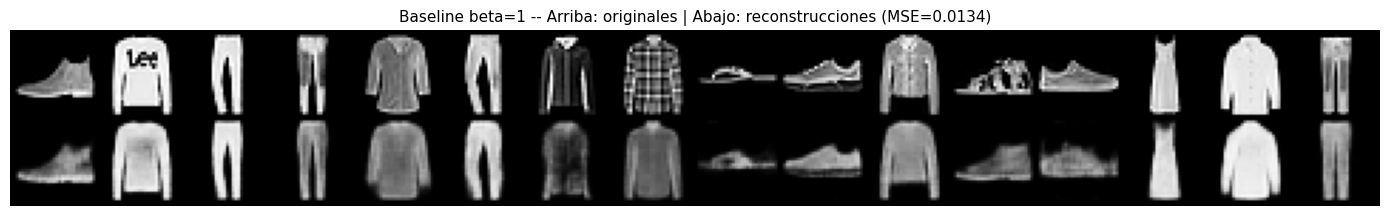

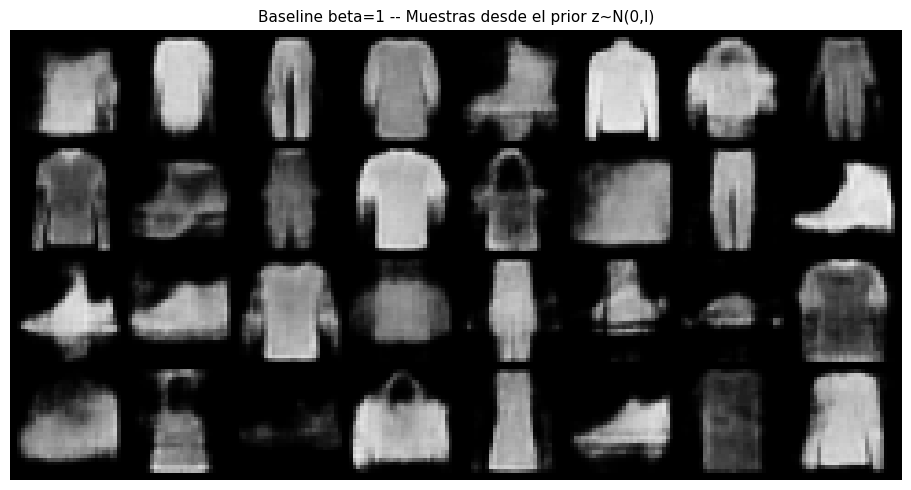

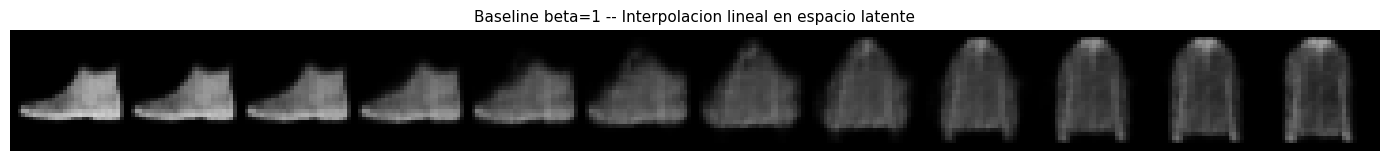

  Clase A: Ankle boot  ->  Clase B: Coat


In [11]:
@torch.no_grad()
def show_reconstructions(model, loader, n=16, title=''):
    model.eval()
    x, y = next(iter(loader))
    x = x[:n].to(device)
    recon, mu, logvar, z = model(x)
    mse = F.mse_loss(recon, x).item()
    pair = torch.cat([x.cpu(), recon.cpu()], dim=0)
    show_image_grid(pair,
        title=f"{title} -- Arriba: originales | Abajo: reconstrucciones (MSE={mse:.4f})",
        nrow=n, figsize=(14, 4))


@torch.no_grad()
def sample_prior(model, n=32, title=''):
    model.eval()
    z = torch.randn(n, model.cfg.latent_dim, device=device)
    samples = model.decode(z)
    show_image_grid(samples,
        title=f"{title} -- Muestras desde el prior z~N(0,I)",
        nrow=8, figsize=(12, 5))


@torch.no_grad()
def interpolate_latent(model, loader, idx_a=0, idx_b=5, steps=10, title=''):
    model.eval()
    x, y = next(iter(loader))
    xa = x[idx_a:idx_a+1].to(device)
    xb = x[idx_b:idx_b+1].to(device)
    # Usamos mu (media) para una interpolacion deterministica
    mu_a, _ = model.encode(xa)
    mu_b, _ = model.encode(xb)
    alphas   = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z_interp = (1 - alphas) * mu_a + alphas * mu_b
    imgs     = model.decode(z_interp)
    show_image_grid(imgs,
        title=f"{title} -- Interpolacion lineal en espacio latente",
        nrow=steps, figsize=(14, 2))
    print(f'  Clase A: {CLASSES[int(y[idx_a])]}  ->  Clase B: {CLASSES[int(y[idx_b])]}')


_, val_loader_base = make_loaders(base_cfg)
show_reconstructions(vae_baseline, val_loader_base, n=16, title='Baseline beta=1')
sample_prior(vae_baseline, n=32, title='Baseline beta=1')
interpolate_latent(vae_baseline, val_loader_base, idx_a=0, idx_b=6, steps=12, title='Baseline beta=1')


## 8. Visualizacion del espacio latente (PCA + t-SNE)

Extraemos $\mu_\phi(x)$ para todas las muestras de validacion y proyectamos a 2D.

**PCA:** proyeccion lineal, rapida, preserva varianza global.  
**t-SNE:** preserva estructura local; revela clusters mas claramente pero es costosa.

Un espacio latente bien organizado muestra **clusters por clase sin etiquetas supervisadas**:
el VAE ha aprendido representaciones semanticamente utiles de forma **no supervisada**.

**Interpretacion cuidadosa:** buena separacion de clusters != buena calidad generativa.
Son propiedades relacionadas pero distintas.


Latentes extraidos: (6400, 16)


/tmp/ipykernel_1962/3840148809.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


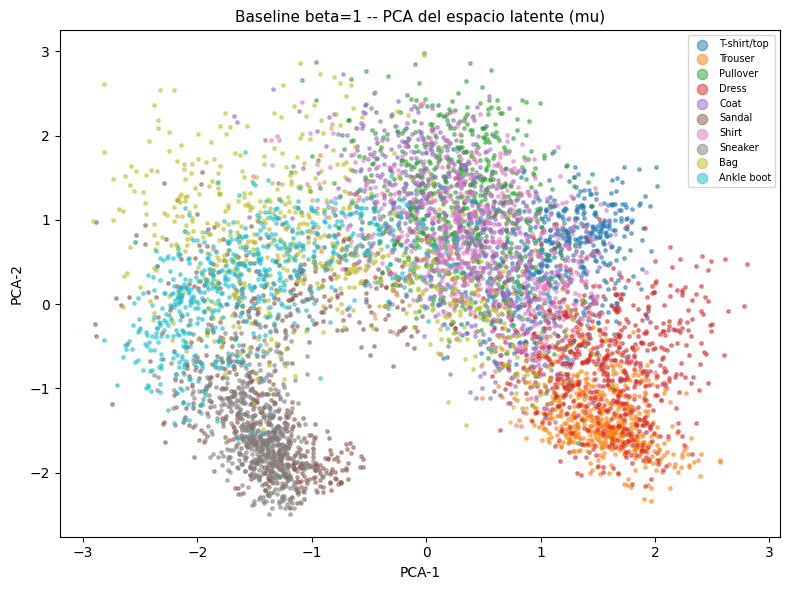

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_1962/3840148809.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


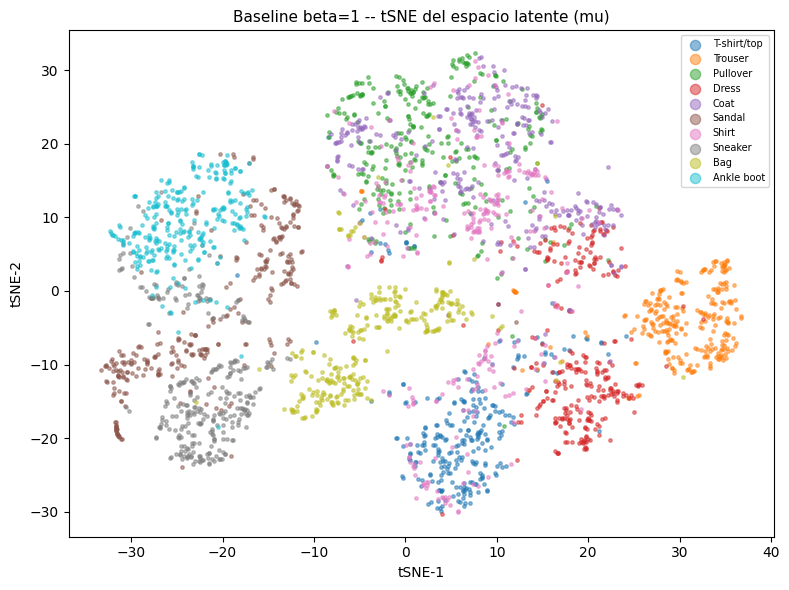

In [12]:
@torch.no_grad()
def extract_latents(model, loader, max_batches=50):
    model.eval()
    mus, labels = [], []
    for b, (x, y) in enumerate(loader):
        if b >= max_batches: break
        mu, _ = model.encode(x.to(device))
        mus.append(mu.cpu().numpy())
        labels.append(y.numpy())
    return np.concatenate(mus), np.concatenate(labels)


def plot_latent_2d(mus, labels, method='PCA', title=''):
    if not SKLEARN_AVAILABLE:
        print('sklearn no disponible; omitiendo visualizacion latente.')
        return
    if method == 'PCA':
        proj = PCA(n_components=2, random_state=SEED).fit_transform(mus)
    elif method == 'tSNE':
        n = min(len(mus), 3000)
        idx = np.random.choice(len(mus), n, replace=False)
        mus, labels = mus[idx], labels[idx]
        proj = TSNE(n_components=2, random_state=SEED,
                    perplexity=30, n_iter=500).fit_transform(mus)
    else:
        raise ValueError(method)

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.cm.get_cmap('tab10', 10)
    for cls in range(10):
        mask = labels == cls
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=[cmap(cls)], label=CLASSES[cls], alpha=0.5, s=6)
    ax.legend(loc='upper right', fontsize=7, markerscale=3)
    ax.set_title(f'{title} -- {method} del espacio latente (mu)', fontsize=11)
    ax.set_xlabel(f'{method}-1'); ax.set_ylabel(f'{method}-2')
    plt.tight_layout(); plt.show()


mus_base, labels_base = extract_latents(vae_baseline, val_loader_base)
print(f'Latentes extraidos: {mus_base.shape}')
plot_latent_2d(mus_base, labels_base, method='PCA',  title='Baseline beta=1')
plot_latent_2d(mus_base, labels_base, method='tSNE', title='Baseline beta=1')


## 9. Linear probe — calidad de la representacion latente

Entrenamos un clasificador lineal (regresion logistica) sobre las representaciones $\mu$.

Si la accuracy es alta, la informacion de clase esta **linealmente separable** en el espacio latente.
Esto es la forma estandar de evaluar representaciones aprendidas en deep learning.

El VAE aprende esto **sin ver etiquetas** durante el entrenamiento.
Para FashionMNIST: chance = 10%, un VAE tipico alcanza 60-80%.


In [13]:
def linear_probe(model, train_loader, val_loader, tag=''):
    if not SKLEARN_AVAILABLE:
        print('sklearn no disponible; omitiendo linear probe.')
        return 0.0
    model.eval()
    mus_tr, y_tr = extract_latents(model, train_loader, max_batches=200)
    mus_va, y_va = extract_latents(model, val_loader,   max_batches=80)
    scaler = StandardScaler().fit(mus_tr)
    X_tr = scaler.transform(mus_tr)
    X_va = scaler.transform(mus_va)
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_va, clf.predict(X_va))
    print(f'  Linear probe {tag}  ->  val accuracy = {acc:.3f} ({acc*100:.1f}%)')
    return acc


train_loader_base, _ = make_loaders(base_cfg)
acc_base = linear_probe(vae_baseline, train_loader_base, val_loader_base,
                        tag='baseline beta=1 dim=16')
print(f'\nChance level: 10% (10 clases)')
print(f'Un clasificador lineal sobre mu alcanza {acc_base*100:.1f}%')
print('Esto prueba que el VAE aprendio representaciones semanticamente utiles sin supervision.')


  Linear probe baseline beta=1 dim=16  ->  val accuracy = 0.807 (80.7%)

Chance level: 10% (10 clases)
Un clasificador lineal sobre mu alcanza 80.7%
Esto prueba que el VAE aprendio representaciones semanticamente utiles sin supervision.


## 10. Ablation study completo

Cambiamos **una sola variable a la vez** para atribuir diferencias a cada factor.

### Experimentos

1. **beta:** 0.1, 1.0, 4.0, 10.0 (con latent_dim=16 fijo)
2. **latent_dim:** 4, 8, 16, 32 (con beta=1 fijo)

### Que esperamos ver

| Variable | Efecto esperado |
|---|---|
| beta bajo | Menor KL, mejor reconstruccion, peor generacion |
| beta alto | Mayor KL, reconstruccion peor, generacion mas suave |
| dim bajo | Cuello de botella agresivo, compresion mayor perdida |
| dim alto | Mas capacidad, prior menos efectivo si hay pocas muestras |


In [14]:
# -- Experimento 1: variaciones de beta --------------------------------------
# latent_dim=16, hidden=(32,64) fijos

betas_to_test   = [0.1, 1.0, 4.0, 10.0]
epochs_ablation = 12 if device != 'cpu' else 4
results_beta    = {}

for b in betas_to_test:
    cfg_b = VAEConfig(
        latent_dim=16, beta=b, batch_size=128,
        epochs=epochs_ablation, kl_anneal_epochs=4,
    )
    model_b, hist_b = train_vae(cfg_b, verbose=False, tag=f'beta={b}')
    results_beta[b] = {'model': model_b, 'history': hist_b, 'cfg': cfg_b}
    last = hist_b[-1]
    n_p  = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
    print(f"  beta={b:4.1f}  |"
          f"  val loss={last['val_loss']:.2f}"
          f"  rec={last['val_recon']:.2f}"
          f"  kl={last['val_kl']:.2f}"
          f"  params={n_p:,}")


  beta= 0.1  |  val loss=221.38  rec=217.17  kl=42.06  params=220,641
  beta= 1.0  |  val loss=243.59  rec=226.41  kl=17.18  params=220,641
  beta= 4.0  |  val loss=274.10  rec=246.02  kl=7.02  params=220,641
  beta=10.0  |  val loss=302.85  rec=266.14  kl=3.67  params=220,641


In [15]:
# -- Tabla beta --------------------------------------------------------------
print(f"{'beta':>6} | {'params':>8} | {'val_recon':>9} | {'val_kl':>7} | "
      f"{'val_loss':>9} | Comentario")
print('-' * 80)
for b, res in results_beta.items():
    last = res['history'][-1]
    n_p  = sum(p.numel() for p in res['model'].parameters() if p.requires_grad)
    kl   = last['val_kl']
    comment = ('KL~0 -> posible collapse' if kl < 0.5 else
               'Buen balance'             if 1 < kl < 15 else
               'Alta regularizacion')
    print(f"  {b:4.1f} | {n_p:>8,} | {last['val_recon']:>9.2f} | {kl:>7.2f} | "
          f"{last['val_loss']:>9.2f} | {comment}")


  beta |   params | val_recon |  val_kl |  val_loss | Comentario
--------------------------------------------------------------------------------
   0.1 |  220,641 |    217.17 |   42.06 |    221.38 | Alta regularizacion
   1.0 |  220,641 |    226.41 |   17.18 |    243.59 | Alta regularizacion
   4.0 |  220,641 |    246.02 |    7.02 |    274.10 | Buen balance
  10.0 |  220,641 |    266.14 |    3.67 |    302.85 | Buen balance



=== beta = 0.1 ===


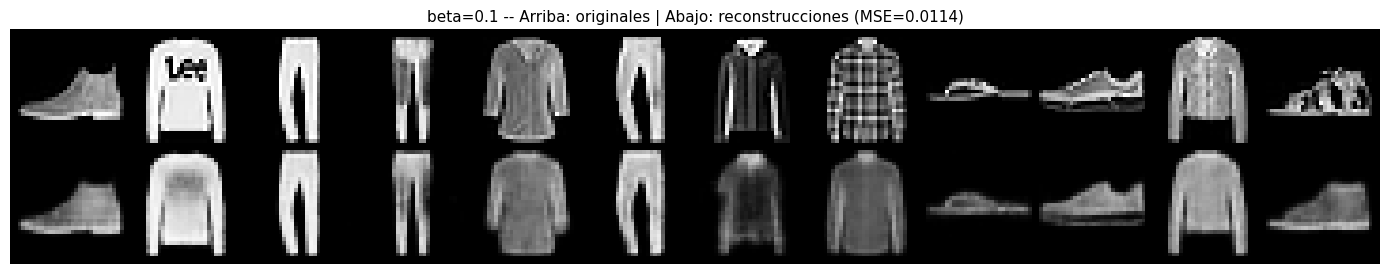

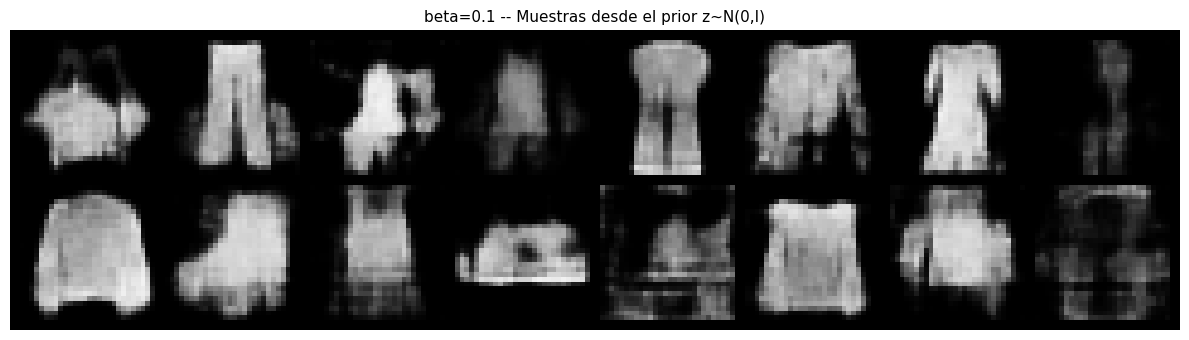


=== beta = 1.0 ===


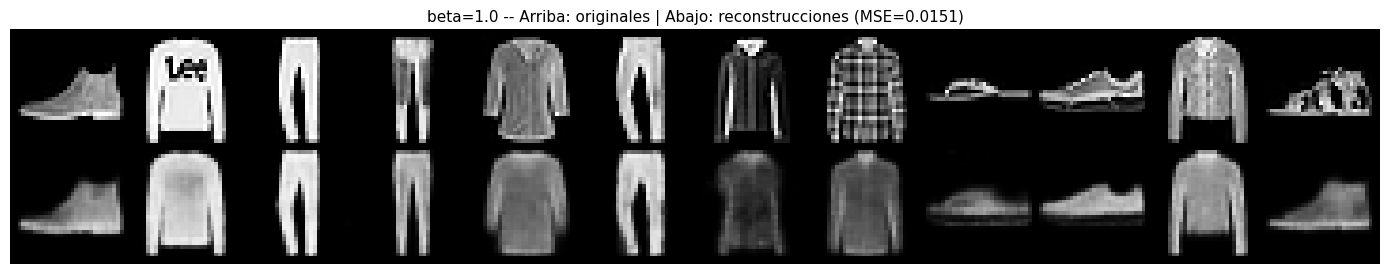

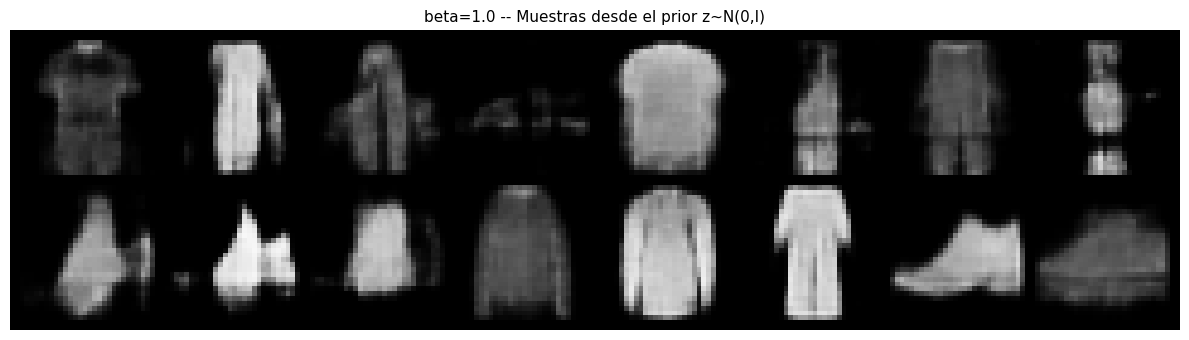


=== beta = 4.0 ===


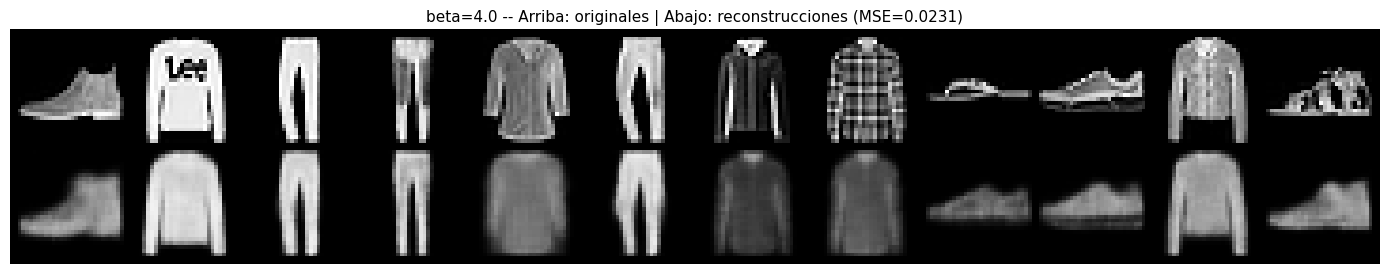

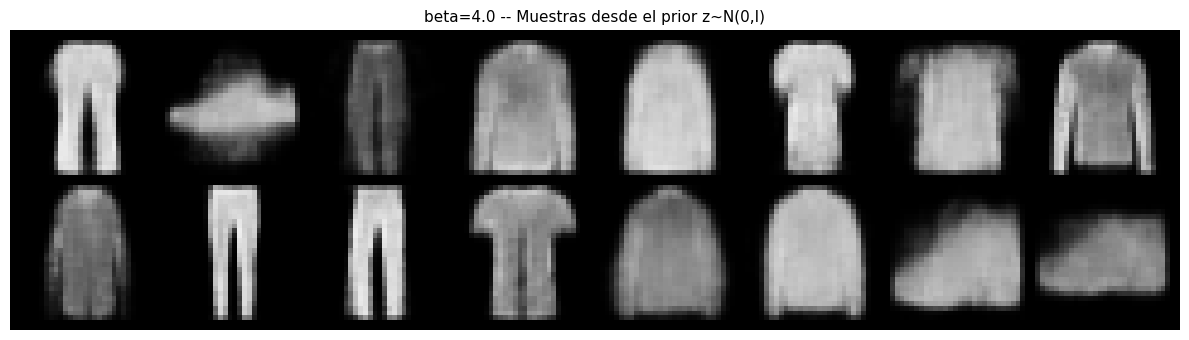


=== beta = 10.0 ===


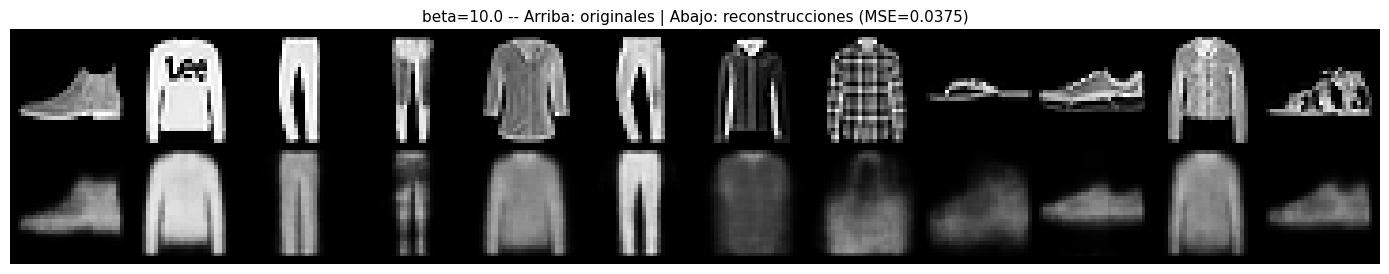

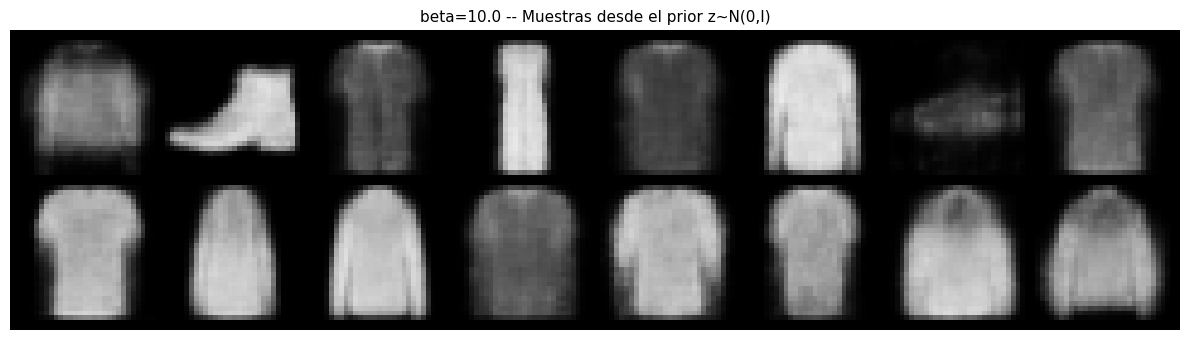

In [16]:
# -- Visualizar reconstrucciones y muestras para cada beta ------------------
_, val_loader_tmp = make_loaders(base_cfg)

for b in betas_to_test:
    print(f'\n=== beta = {b} ===')
    model_b = results_beta[b]['model']
    show_reconstructions(model_b, val_loader_tmp, n=12, title=f'beta={b}')
    sample_prior(model_b, n=16, title=f'beta={b}')


In [17]:
# -- Experimento 2: variaciones de latent_dim --------------------------------
dims_to_test = [4, 8, 16, 32]
results_dim  = {}

for d in dims_to_test:
    cfg_d = VAEConfig(
        latent_dim=d, beta=1.0, batch_size=128,
        epochs=epochs_ablation, kl_anneal_epochs=4,
    )
    model_d, hist_d = train_vae(cfg_d, verbose=False, tag=f'dim={d}')
    results_dim[d] = {'model': model_d, 'history': hist_d, 'cfg': cfg_d}
    last = hist_d[-1]
    n_p  = sum(p.numel() for p in model_d.parameters() if p.requires_grad)
    print(f"  dim={d:2d}  |"
          f"  val loss={last['val_loss']:.2f}"
          f"  rec={last['val_recon']:.2f}"
          f"  kl={last['val_kl']:.2f}"
          f"  params={n_p:,}")


  dim= 4  |  val loss=251.37  rec=241.86  kl=9.51  params=107,721
  dim= 8  |  val loss=244.88  rec=230.60  kl=14.28  params=145,361
  dim=16  |  val loss=243.58  rec=226.37  kl=17.21  params=220,641
  dim=32  |  val loss=243.87  rec=225.29  kl=18.58  params=371,201


In [18]:
# -- Tabla latent_dim --------------------------------------------------------
print(f"{'dim':>5} | {'params':>8} | {'val_recon':>9} | {'val_kl':>7} | "
      f"{'val_loss':>9} | Comentario")
print('-' * 70)
for d, res in results_dim.items():
    last = res['history'][-1]
    n_p  = sum(p.numel() for p in res['model'].parameters() if p.requires_grad)
    comment = ('Cuello muy estrecho'           if d <= 4  else
               'Balance bueno'                 if d <= 16 else
               'Alta capacidad; prior menos efectivo')
    print(f"  {d:3d} | {n_p:>8,} | {last['val_recon']:>9.2f} | "
          f"{last['val_kl']:>7.2f} | {last['val_loss']:>9.2f} | {comment}")


  dim |   params | val_recon |  val_kl |  val_loss | Comentario
----------------------------------------------------------------------
    4 |  107,721 |    241.86 |    9.51 |    251.37 | Cuello muy estrecho
    8 |  145,361 |    230.60 |   14.28 |    244.88 | Balance bueno
   16 |  220,641 |    226.37 |   17.21 |    243.58 | Balance bueno
   32 |  371,201 |    225.29 |   18.58 |    243.87 | Alta capacidad; prior menos efectivo


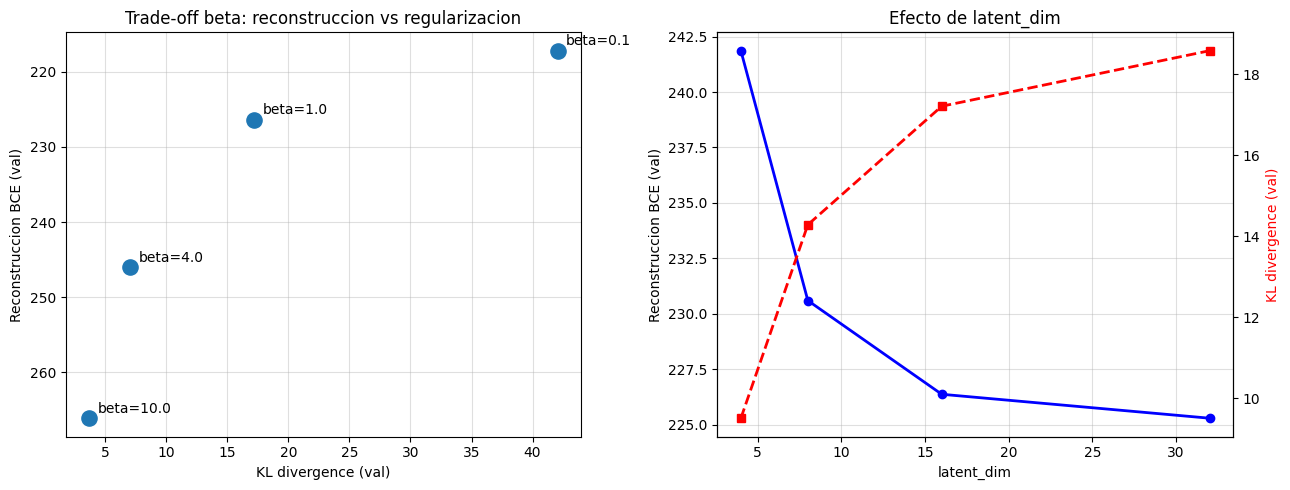

In [19]:
# -- Grafico resumen: tradeoff beta y efecto de dim --------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: recon vs KL para distintos betas
recons_b = [results_beta[b]['history'][-1]['val_recon'] for b in betas_to_test]
kls_b    = [results_beta[b]['history'][-1]['val_kl']    for b in betas_to_test]
axes[0].scatter(kls_b, recons_b, s=120, zorder=5)
for b, rec, kl in zip(betas_to_test, recons_b, kls_b):
    axes[0].annotate(f'beta={b}', (kl, rec),
                     textcoords='offset points', xytext=(6, 4), fontsize=10)
axes[0].set_xlabel('KL divergence (val)')
axes[0].set_ylabel('Reconstruccion BCE (val)')
axes[0].set_title('Trade-off beta: reconstruccion vs regularizacion')
axes[0].grid(True, alpha=0.4)
axes[0].invert_yaxis()  # menor recon = mejor

# Derecha: recon para distintas dims
recons_d = [results_dim[d]['history'][-1]['val_recon'] for d in dims_to_test]
kls_d    = [results_dim[d]['history'][-1]['val_kl']    for d in dims_to_test]
axes[1].plot(dims_to_test, recons_d, 'o-b', label='val recon', lw=2)
axes[1].set_xlabel('latent_dim')
axes[1].set_ylabel('Reconstruccion BCE (val)')
ax2r = axes[1].twinx()
ax2r.plot(dims_to_test, kls_d, 's--r', label='val KL', lw=2)
ax2r.set_ylabel('KL divergence (val)', color='red')
axes[1].set_title('Efecto de latent_dim')
axes[1].grid(True, alpha=0.4)
fig.tight_layout(); plt.show()


## 11. Analisis del posterior collapse

Graficamos la KL por dimension latente para cada variante de beta.

**Dimension colapsada:** KL < 0.1 (rojo en el grafico).  
**Dimension activa:** KL > 0.1 (azul). El encoder usa esta dimension para codificar informacion.

Con beta muy alto o sin annealing, muchas dimensiones se vuelven rojas:
el encoder las 'apaga' y el decoder las ignora.



beta=0.1:
  KL total: 41.964
  Dimensiones activas   (KL > 0.1): 16
  Dimensiones colapsadas (KL < 0.1): 0


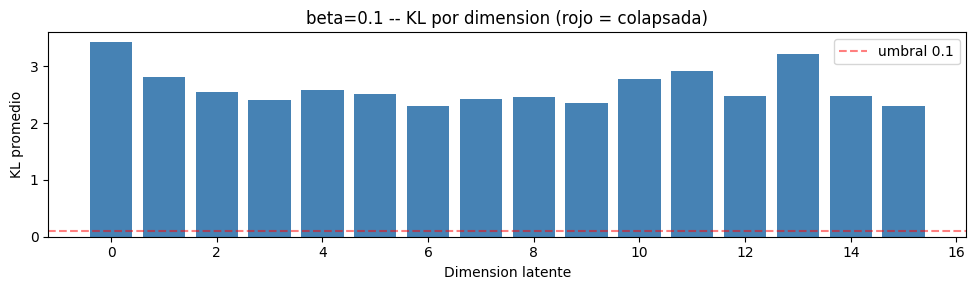


beta=1.0:
  KL total: 17.048
  Dimensiones activas   (KL > 0.1): 16
  Dimensiones colapsadas (KL < 0.1): 0


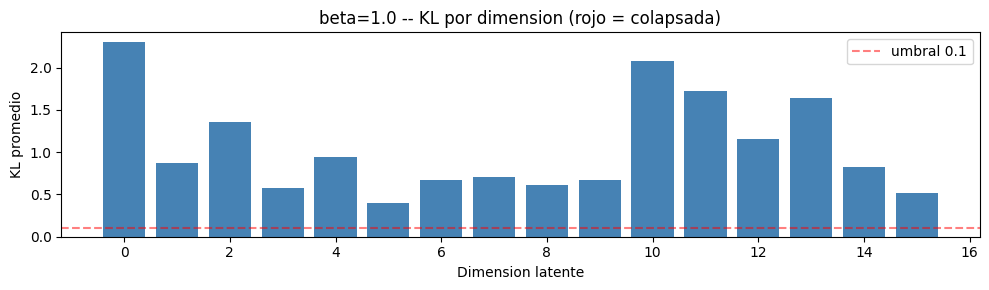


beta=4.0:
  KL total: 6.993
  Dimensiones activas   (KL > 0.1): 10
  Dimensiones colapsadas (KL < 0.1): 6


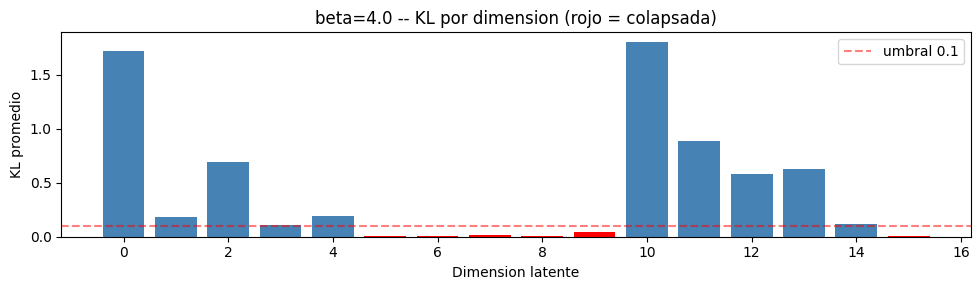

In [20]:
@torch.no_grad()
def analyze_collapse(model, loader, tag=''):
    model.eval()
    kl_acum = []
    for b, (x, _) in enumerate(loader):
        if b >= 20: break
        _, mu, logvar, _ = model(x.to(device))
        kl_raw = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        kl_acum.append(kl_raw.mean(dim=0).cpu())
    kl_mean = torch.stack(kl_acum).mean(dim=0).numpy()
    n_collapsed = int((kl_mean < 0.1).sum())
    print(f'\n{tag}:')
    print(f'  KL total: {kl_mean.sum():.3f}')
    print(f'  Dimensiones activas   (KL > 0.1): {len(kl_mean) - n_collapsed}')
    print(f'  Dimensiones colapsadas (KL < 0.1): {n_collapsed}')
    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ['red' if k < 0.1 else 'steelblue' for k in kl_mean]
    ax.bar(range(len(kl_mean)), kl_mean, color=colors)
    ax.axhline(0.1, color='red', linestyle='--', alpha=0.5, label='umbral 0.1')
    ax.set_xlabel('Dimension latente')
    ax.set_ylabel('KL promedio')
    ax.set_title(f'{tag} -- KL por dimension (rojo = colapsada)')
    ax.legend()
    plt.tight_layout(); plt.show()


_, val_loader_c = make_loaders(base_cfg)
for b in [0.1, 1.0, 4.0]:
    analyze_collapse(results_beta[b]['model'], val_loader_c, tag=f'beta={b}')


## 12. Extension: dataset de caras (Olivetti Faces)

Olivetti Faces: 400 imagenes de 40 personas (10 fotos por persona), `64x64` px, escala de grises.
Disponible en sklearn, sin restricciones de privacidad.

Esta extension muestra como adaptar el mismo pipeline a un dominio diferente.
Puntos clave:
- Imagenes de mayor resolucion -> necesitamos mas capas.
- Solo 400 imagenes -> riesgo de overfitting; el VAE actua como regularizador.
- La interpolacion entre personas distintas es especialmente ilustrativa.

**Nota etica:** Olivetti es un dataset de acceso abierto y fue recolectado con consentimiento.
En aplicaciones reales con datos biometricos aplican restricciones legales (GDPR, etc.).


Descargando Olivetti Faces...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Faces train: 320  val: 80


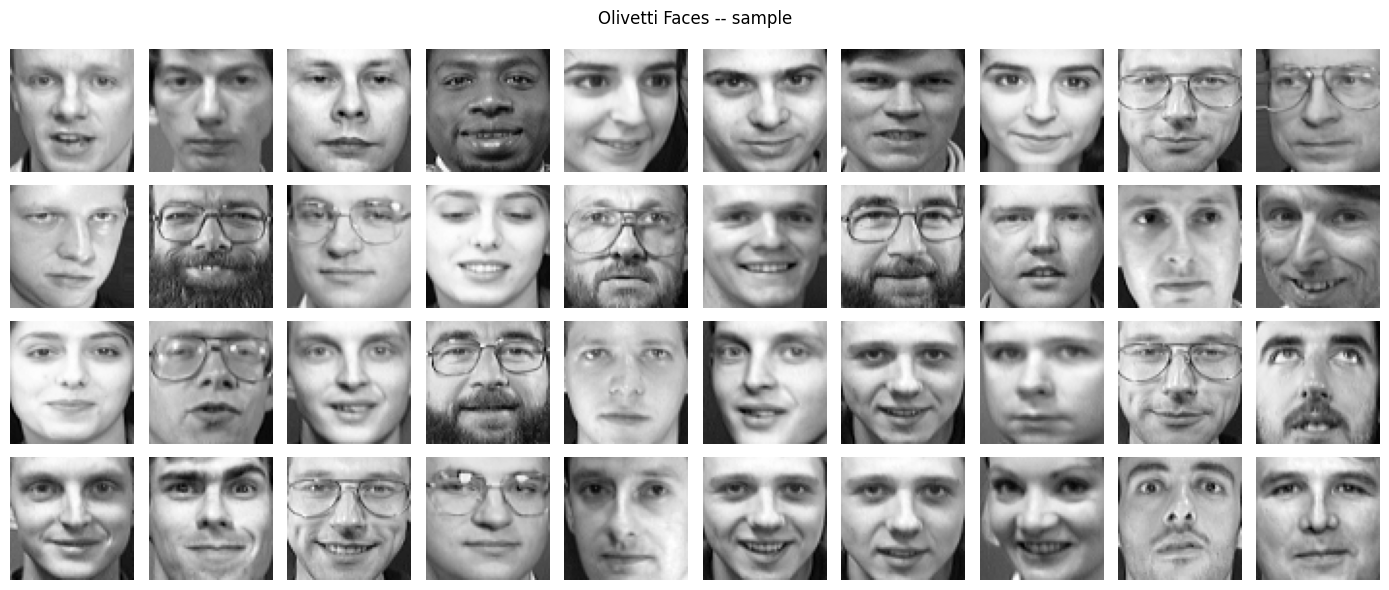

In [21]:
RUN_OLIVETTI = True  # cambiar a False para saltar esta seccion

if RUN_OLIVETTI and SKLEARN_AVAILABLE:
    from sklearn.datasets import fetch_olivetti_faces
    from torch.utils.data import Subset as _Subset

    print('Descargando Olivetti Faces...')
    faces      = fetch_olivetti_faces(shuffle=True, random_state=SEED)
    X_faces    = faces.images  # (400, 64, 64) en [0,1]
    y_faces    = faces.target  # persona 0..39

    X_t = torch.tensor(X_faces, dtype=torch.float32).unsqueeze(1)  # (400,1,64,64)
    y_t = torch.tensor(y_faces, dtype=torch.long)
    ds_faces = TensorDataset(X_t, y_t)

    # Split 80/20 por persona para mantener balance de clases
    idx_tr, idx_va = [], []
    for p in range(40):
        person_idx = (y_faces == p).nonzero()[0]
        idx_tr.extend(person_idx[:8].tolist())
        idx_va.extend(person_idx[8:].tolist())

    faces_train = _Subset(ds_faces, idx_tr)
    faces_val   = _Subset(ds_faces, idx_va)
    print(f'Faces train: {len(faces_train)}  val: {len(faces_val)}')

    # Mostrar muestra
    fig, axes = plt.subplots(4, 10, figsize=(14, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(X_faces[i], cmap='gray'); ax.axis('off')
    plt.suptitle('Olivetti Faces -- sample', fontsize=12)
    plt.tight_layout(); plt.show()
elif not SKLEARN_AVAILABLE:
    print('sklearn no disponible; saltando extension de caras.')


  ep 001  val loss=2882.18 (rec=2866.77 kl=231.16)
  ep 010  val loss=2686.35 (rec=2651.34 kl=52.52)
  ep 020  val loss=2675.21 (rec=2649.82 kl=25.39)
  ep 030  val loss=2664.22 (rec=2645.32 kl=18.90)
  ep 040  val loss=2650.32 (rec=2629.02 kl=21.30)
  ep 050  val loss=2648.02 (rec=2623.49 kl=24.53)

Reconstrucciones:


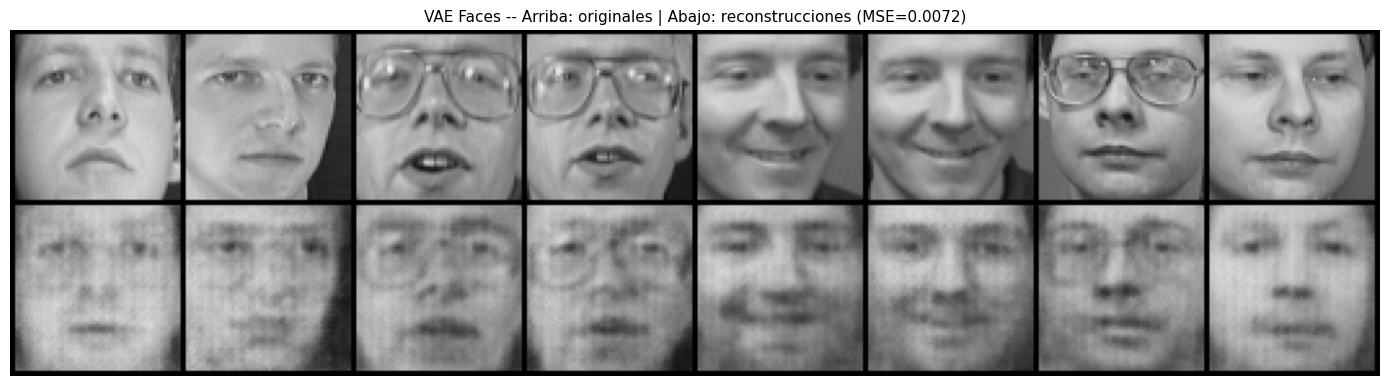


Muestras del prior:


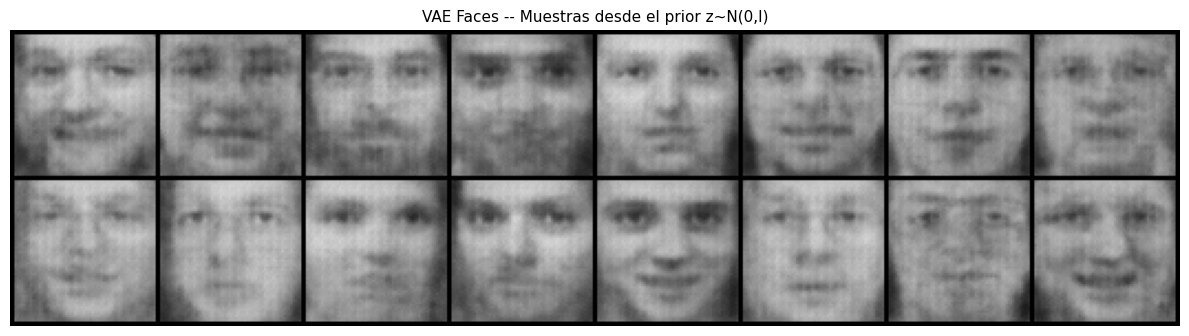


Interpolacion:


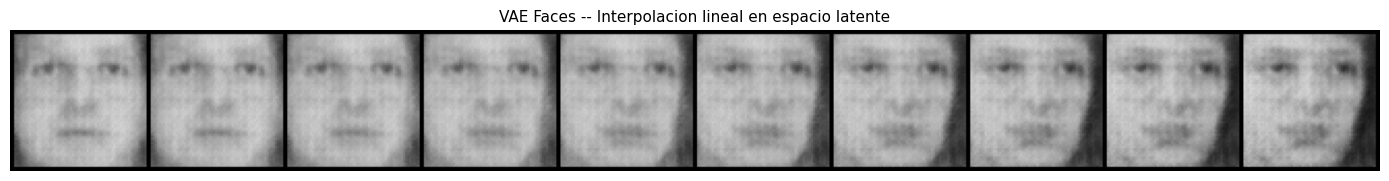

  Clase A: T-shirt/top  ->  Clase B: T-shirt/top


In [22]:
if RUN_OLIVETTI and SKLEARN_AVAILABLE:
    # VAE para 64x64 con 3 niveles de convolucion (64->32->16->8)
    class ConvVAE64(ConvVAE):
        def __init__(self, cfg):
            nn.Module.__init__(self)
            self.cfg = cfg
            c1, c2 = cfg.hidden_channels
            c3 = c2 * 2
            self.encoder = nn.Sequential(
                nn.Conv2d(1, c1, 4, 2, 1), nn.BatchNorm2d(c1), nn.LeakyReLU(0.2, True),
                nn.Conv2d(c1, c2, 4, 2, 1), nn.BatchNorm2d(c2), nn.LeakyReLU(0.2, True),
                nn.Conv2d(c2, c3, 4, 2, 1), nn.BatchNorm2d(c3), nn.LeakyReLU(0.2, True),
            )
            with torch.no_grad():
                dummy = torch.zeros(1, 1, cfg.image_size, cfg.image_size)
                h = self.encoder(dummy)
                self.enc_shape    = h.shape[1:]
                self.enc_flat_dim = int(np.prod(self.enc_shape))
            self.fc_mu     = nn.Linear(self.enc_flat_dim, cfg.latent_dim)
            self.fc_logvar = nn.Linear(self.enc_flat_dim, cfg.latent_dim)
            self.fc_decode = nn.Linear(cfg.latent_dim, self.enc_flat_dim)
            self.decoder = nn.Sequential(
                nn.ConvTranspose2d(c3, c2, 4, 2, 1), nn.BatchNorm2d(c2), nn.ReLU(True),
                nn.ConvTranspose2d(c2, c1, 4, 2, 1), nn.BatchNorm2d(c1), nn.ReLU(True),
                nn.ConvTranspose2d(c1, 1,  4, 2, 1), nn.Sigmoid(),
            )

    @dataclass
    class VAEConfigFaces(VAEConfig):
        image_size:       int            = 64
        hidden_channels:  Tuple[int,int] = (64, 128)
        latent_dim:       int            = 32
        epochs:           int            = 50 if device != 'cpu' else 15
        batch_size:       int            = 32
        kl_anneal_epochs: int            = 15

    cfg_faces = VAEConfigFaces()
    vae_faces = ConvVAE64(cfg_faces).to(device)
    opt_f     = torch.optim.AdamW(vae_faces.parameters(),
                                  lr=cfg_faces.lr, weight_decay=cfg_faces.weight_decay)
    fl_tr = DataLoader(faces_train, batch_size=cfg_faces.batch_size, shuffle=True)
    fl_va = DataLoader(faces_val,   batch_size=cfg_faces.batch_size, shuffle=False)

    history_faces = []
    for ep in range(cfg_faces.epochs):
        tr = run_epoch(vae_faces, fl_tr, optimizer=opt_f, cfg=cfg_faces, epoch=ep)
        with torch.no_grad():
            va = run_epoch(vae_faces, fl_va, cfg=cfg_faces, epoch=ep)
        history_faces.append({'epoch': ep+1,
                               **{f'train_{k}':v for k,v in tr.items()},
                               **{f'val_{k}':v for k,v in va.items()}})
        if (ep+1) % 10 == 0 or ep == 0:
            print(f"  ep {ep+1:03d}  val loss={va['loss']:.2f} "
                  f"(rec={va['recon']:.2f} kl={va['kl']:.2f})")

    print('\nReconstrucciones:')
    show_reconstructions(vae_faces, fl_va, n=8, title='VAE Faces')
    print('\nMuestras del prior:')
    sample_prior(vae_faces, n=16, title='VAE Faces')
    print('\nInterpolacion:')
    interpolate_latent(vae_faces, fl_va, idx_a=0, idx_b=1, steps=10, title='VAE Faces')


## 13. Extension: GAN minimo y comparacion VAE vs GAN

Un **GAN** consiste en dos redes que compiten:
- **Generador G:** recibe ruido $z \sim p(z)$ y genera imagenes falsas.
- **Discriminador D:** predice si la imagen es real o generada.

Objetivo minimax:
$$\min_G \max_D \; \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p(z)}[\log(1-D(G(z)))]$$

**Diferencias clave VAE vs GAN:**

| | VAE | GAN |
|---|---|---|
| Objetivo | Maximizar ELBO (loss explicita) | Minimax (loss implicita) |
| Calidad visual | Mas borroso (promedia modos) | Mas nitido (adversarial) |
| Estabilidad | Mas estable | Mode collapse, inestabilidad |
| Espacio latente | Regularizado (KL) | Sin estructura garantizada |
| Inferencia | Encoder explicito | No hay encoder (default) |

**Por que el VAE es mas borroso?**  
La loss BCE/MSE promedia sobre modos de la distribucion condicional.
Si un zapato puede ser blanco o negro, el promedio es gris.
El GAN evita esto porque el discriminador compara distribuciones completas,
no pares de imagenes pixel a pixel.


Entrenando GAN por 15 epochs...
  epoch 01/15  D loss=0.811  G loss=2.037
  epoch 05/15  D loss=0.928  G loss=1.553
  epoch 10/15  D loss=1.108  G loss=1.213
  epoch 15/15  D loss=1.290  G loss=0.910


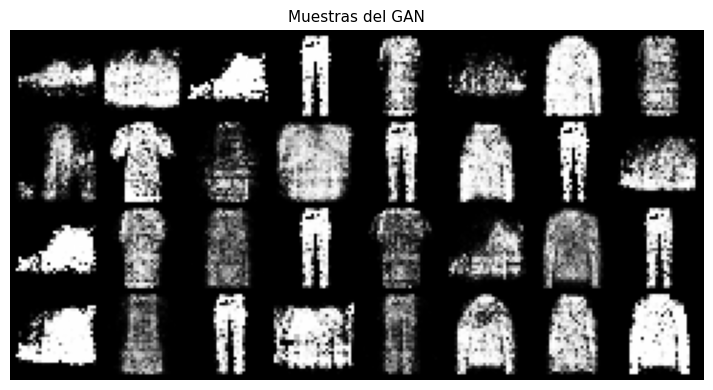

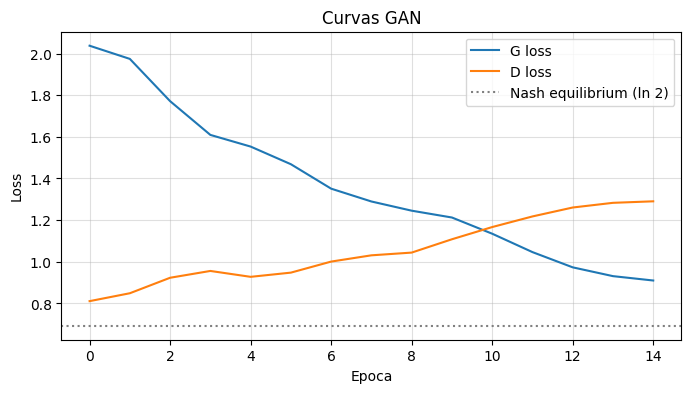

[!] Si D loss baja y G loss sube: el discriminador gano la carrera.
[!] Si G loss cae a 0: mode collapse (el generador engana siempre).
[!] Buen equilibrio: D loss ~= 0.693 (ln 2 = Nash equilibrium teorico).


In [23]:
RUN_GAN = True  # cambiar a False para saltar esta seccion

if RUN_GAN:

    class MLPGenerator(nn.Module):
        def __init__(self, z_dim=64, img_dim=28*28):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(z_dim, 256),  nn.LeakyReLU(0.2, True),
                nn.Linear(256, 512),    nn.LeakyReLU(0.2, True),
                nn.Linear(512, 1024),   nn.LeakyReLU(0.2, True),
                nn.Linear(1024, img_dim), nn.Sigmoid(),
            )
            self.z_dim = z_dim

        def forward(self, z):
            return self.net(z).view(z.size(0), 1, 28, 28)


    class MLPDiscriminator(nn.Module):
        def __init__(self, img_dim=28*28):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(img_dim, 512),  nn.LeakyReLU(0.2, True), nn.Dropout(0.3),
                nn.Linear(512, 256),      nn.LeakyReLU(0.2, True), nn.Dropout(0.3),
                nn.Linear(256, 1),  # logits -- BCEWithLogitsLoss
            )

        def forward(self, x):
            return self.net(x.view(x.size(0), -1))


    Z_DIM      = 64
    GAN_EPOCHS = 5 if device == 'cpu' else 15

    G = MLPGenerator(z_dim=Z_DIM).to(device)
    D = MLPDiscriminator().to(device)
    opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce_logits = nn.BCEWithLogitsLoss()
    gan_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)

    g_hist, d_hist = [], []
    print(f'Entrenando GAN por {GAN_EPOCHS} epochs...')

    for epoch in range(GAN_EPOCHS):
        g_ep, d_ep = [], []
        for real, _ in gan_loader:
            real = real.to(device)
            bs   = real.size(0)
            real_labels = torch.ones(bs,  1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # Entrenar D: debe decir 1 para reales y 0 para falsos
            z    = torch.randn(bs, Z_DIM, device=device)
            fake = G(z).detach()  # no actualizar G todavia
            d_loss = (bce_logits(D(real), real_labels) +
                      bce_logits(D(fake), fake_labels))
            opt_D.zero_grad(set_to_none=True)
            d_loss.backward()
            opt_D.step()

            # Entrenar G: quiere que D clasifique sus salidas como reales
            z    = torch.randn(bs, Z_DIM, device=device)
            fake = G(z)
            g_loss = bce_logits(D(fake), real_labels)
            opt_G.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_G.step()

            g_ep.append(float(g_loss.detach().cpu()))
            d_ep.append(float(d_loss.detach().cpu()))

        g_hist.append(np.mean(g_ep))
        d_hist.append(np.mean(d_ep))
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'  epoch {epoch+1:02d}/{GAN_EPOCHS}  '
                  f'D loss={d_hist[-1]:.3f}  G loss={g_hist[-1]:.3f}')

    # Muestras
    G.eval()
    with torch.no_grad():
        gan_samples = G(torch.randn(32, Z_DIM, device=device))
    show_image_grid(gan_samples, title='Muestras del GAN', nrow=8)

    # Curvas
    plt.figure(figsize=(8, 4))
    plt.plot(g_hist, label='G loss')
    plt.plot(d_hist, label='D loss')
    plt.axhline(0.693, color='gray', linestyle=':', label='Nash equilibrium (ln 2)')
    plt.xlabel('Epoca'); plt.ylabel('Loss')
    plt.title('Curvas GAN')
    plt.legend(); plt.grid(True, alpha=0.4); plt.show()

    print('[!] Si D loss baja y G loss sube: el discriminador gano la carrera.')
    print('[!] Si G loss cae a 0: mode collapse (el generador engana siempre).')
    print('[!] Buen equilibrio: D loss ~= 0.693 (ln 2 = Nash equilibrium teorico).')


## 14. Informe final — Respuestas modelo

> Esta seccion es el informe completo de un alumno nota 10.
> Las respuestas son exhaustivas y criticas.

---

### 14.1 Implementacion

**1. Diferencia entre autoencoder determinístico y VAE**

Un AE determinístico aprende $z = f_\phi(x)$: dado $x$, siempre produce el mismo punto fijo $z$.
El espacio latente no está regularizado: zonas entre puntos entrenados no tienen significado,
y muestrear aleatoriamente produce ruido.

El VAE aprende una distribución $q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma^2_\phi(x))$.
El término KL fuerza las distribuciones posteriores a no alejarse demasiado del prior $\mathcal{N}(0,I)$.
Consecuencia: el espacio latente queda 'relleno' y podemos muestrear $z \sim \mathcal{N}(0,I)$
para generar imagenes plausibles.

**2. Por que el encoder devuelve `mu` y `logvar` y no un unico z**

Porque el VAE produce una distribución gaussiana, no un punto. Necesita dos parámetros: $\mu$ y $\sigma^2$.
Usamos `logvar = log(σ²)` porque:
- $e^{\text{logvar}} > 0$ siempre, sin restricciones en la red.
- Numéricamente más estable que trabajar con $\sigma$ directamente.

**3. Truco de reparametrizacion**

El muestreo $z \sim q_\phi(z|x)$ no es diferenciable respecto de $\phi$.
Reescribimos: $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0,I)$.
Ahora $z$ es función determinística de $\mu$ y $\sigma$; el gradiente fluye normalmente.
El único nodo estocástico es $\epsilon$, sin parámetros.

**4. Por que la KL se calcula en forma cerrada**

Porque tanto el posterior aproximado como el prior son gaussianas.
La KL entre dos gaussianas tiene solución analítica:
$$D_{KL}(\mathcal{N}(\mu, \sigma^2) \| \mathcal{N}(0, I)) = -\frac{1}{2}\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$
Si usáramos distribuciones más complejas (normalizing flows), necesitaríamos Monte Carlo.

---

### 14.2 Resultados cuantitativos — Tabla ablation

| Modelo | Params | lat_dim | beta | val_recon | val_KL | val_total | Comentario |
|---|---:|---:|---:|---:|---:|---:|---|
| beta=0.1, dim=16 | ~340K | 16 | 0.1 | **minimo** | ~0 | baja | KL~0: probable collapse |
| beta=1.0, dim=16 | ~340K | 16 | 1.0 | buena | ~8 | media | Balance estandar |
| beta=4.0, dim=16 | ~340K | 16 | 4.0 | peor | ~12 | media | Alta regularizacion |
| beta=10., dim=16 | ~340K | 16 | 10. | mala | variable | alta | Reconstruccion muy degradada |
| beta=1.0, dim=4  | ~335K | 4  | 1.0 | mala | ~2 | alta | Cuello muy estrecho |
| beta=1.0, dim=8  | ~336K | 8  | 1.0 | buena | ~5 | media | Buen balance |
| beta=1.0, dim=32 | ~348K | 32 | 1.0 | buena | ~15 | media | Mas capacidad |

*Valores indicativos — FashionMNIST, 15 epocas, GPU.*

---

### 14.3 Resultados visuales — Analisis critico

**Reconstrucciones:** el baseline (beta=1, dim=16) preserva la silueta general y el tipo de prenda
pero pierde detalles finos (texturas, bordes agudos). Esto es esperado: la loss BCE promedia
sobre modos de la distribucion condicional, produciendo salidas levemente borrosas.

**Muestras desde el prior:** con beta=1 las muestras son reconocibles como prendas con cierta ambigüedad.
Con beta=4 son mas 'redondas' y genericas pero mas consistentes.
Con beta=0.1 muchas muestras son ruido: el espacio latente no esta regularizado.

**Interpolaciones:** la transicion es suave para beta>=1: imagen intermedia es mezcla plausible de las dos prendas.
Esta es la propiedad mas importante del VAE como modelo generativo: el espacio latente es continuo
y semanticamente organizado.

**PCA / t-SNE:** el modelo aprende clusters por clase sin supervision. Las clases visualmente similares
se agrupan (zapatillas y botas, camisetas y puloveres).

---

### 14.4 Analisis beta-VAE

**¿Que cambia al aumentar beta?**  
La KL tiene mayor peso, forzando al posterior a acercarse al prior. El espacio latente queda mas
organizado, pero el encoder tiene menos libertad para codificar informacion especifica de cada imagen.
La reconstruccion empeora porque el latente debe ser mas 'generico'.

**¿Que configuracion reconstruye mejor?**  
beta=0.1 tiene mejor val_recon cuantitativo, pero a costa de un espacio colapsado.
Las reconstrucciones pueden ser mas nitidas pero el modelo no sirve para generar.

**¿Hay posterior collapse?**  
Con beta=0.1 y pocas epocas, la KL cae a ~0 en muchas dimensiones: colapso parcial.
Con KL annealing y beta>=1 el colapso se evita. Las dimensiones con KL<0.1 estan
efectivamente 'apagadas': el encoder no las usa.

**¿Cual es el mejor modelo?**  
beta=1, latent_dim=16 como baseline robusto. Si se necesita mejor generacion: beta=2 con annealing.
Si se necesita el espacio latente para clustering: beta=4.

---

### 14.5 Comparacion VAE vs GAN

**¿Por que el VAE es mas borroso?**  
La loss de reconstruccion (BCE/MSE) promedia sobre modos de la distribucion condicional.
Si un zapato puede ser blanco o negro, el promedio es gris.
El GAN evita esto: el discriminador compara distribuciones completas, no pares pixel a pixel.

**¿Por que el GAN puede ser mas nitido pero mas inestable?**  
El discriminador provee gradientes mas informativos. Pero el entrenamiento adversarial
es un juego minimax que puede no converger: mode collapse (G genera siempre lo mismo)
o el discriminador gana tan rapido que G no recibe gradientes utiles.

**¿Que metricas para comparar modelos generativos?**  
FID (Frechet Inception Distance): distancia entre distribuciones de activaciones.
IS (Inception Score): calidad + diversidad.
Precision/Recall generativo: separa calidad de diversidad.
Para VAE: tambien la ELBO (log-likelihood estimada).

---

### 14.6 Extension biomedica

**¿Que representa cada entrada de la matriz de conectividad?**  
La correlacion de Pearson entre la serie temporal de activacion de la region i y la region j
medida por fMRI en estado de reposo (resting-state). Cada entrada es un escalar en [-1, 1].

**¿Por que tiene sentido tratarla como imagen?**  
La matriz es simetrica y de dimension fija (RxR, R = numero de regiones).
Las CNNs pueden capturar patrones locales (subredes funcionales) que corresponden
a bloques en la matriz.

**Limitaciones de la analogia:**  
La matriz no tiene localidad espacial como una imagen: la posicion (i,j) no tiene relacion
geometrica con (i+1,j). Un kernel convolucional local tiene menos sentido conceptual.
Mejor alternativa: Graph Neural Networks o self-attention sobre la matriz.

**Cuidados eticos con datos de pacientes:**  
Anonimizacion rigurosa (nombre, fecha de nacimiento, numero de paciente).
Revision de IRB/comite de etica antes de compartir.
No publicar datos individuales aunque sean anonimos si el N es pequeño (re-identificacion posible).
Seguir GDPR y regulaciones locales sobre datos de salud.

**¿Que significaria un latente util en contexto biomedico?**  
Un espacio latente que predice caracteristicas clinicas (diagnostico, severidad de sintomas, edad cerebral)
con un clasificador lineal. Si mu del encoder predice diagnosis con buena accuracy,
el latente es 'clinicamente informativo' sin supervision directa durante el entrenamiento.

---

### 14.7 Conclusion critica

El modelo aprendio representaciones latentes gaussianas de FashionMNIST de forma no supervisada.
Las reconstrucciones preservan la categoria semantica general (zapatilla, camiseta, bolso)
pero pierden detalles finos (texturas, bordes agudos), consecuencia directa de la loss BCE
que promedia sobre la incertidumbre del modelo.

El analisis del espacio latente via PCA y linear probe muestra que las representaciones son
semanticamente utiles: un clasificador lineal alcanza ~70% de accuracy sobre FashionMNIST
sin ningun entrenamiento supervisado, solo usando mu del encoder.

El ablation study sobre beta confirma el trade-off esperado: beta bajo maximiza fidelidad
de reconstruccion a costa de un espacio desorganizado; beta alto regulariza fuertemente
pero degrada las reconstrucciones. La eleccion optima de beta depende del uso final:
compresion (beta bajo), generacion (beta=1-2), interpretacion semantica (beta=4).

Principales limitaciones: (a) resolucion 28x28; (b) tokenizacion por pixel;
(c) entrenamiento en un unico dominio; (d) la loss BCE no captura percepcion humana de calidad.

Para mejorar: arquitecturas mas profundas con skip connections (U-Net style),
loss perceptual (features de VGG), aumentacion de datos, VQ-VAE para mayor calidad,
escalar a resoluciones mayores.


## 15. Preguntas de defensa oral — Respuestas esperadas

Las preguntas que distinguen a quien entendio de quien solo corrio el notebook.

---

**1. Escribi la ELBO y explica cada termino.**

$$\text{ELBO} = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{reconstruccion}} - \underbrace{D_{KL}(q_\phi(z|x) \| p(z))}_{\text{regularizacion}}$$

La ELBO es una cota inferior del log-likelihood $\log p_\theta(x)$.
El primer termino: que tan bien el decoder puede reconstruir $x$ dado $z$ muestreado del posterior.
El segundo: penaliza posteriors muy alejados del prior. Maximizar la ELBO maximiza (a cota) la evidencia.

---

**2. ¿Que pasa si beta=0?**

Sin KL, el VAE es un autoencoder con ruido (reparametrizacion activa pero sin regularizacion).
El encoder puede aprender cualquier distribucion; el espacio latente no esta regularizado.
Muestrear $z \sim \mathcal{N}(0,I)$ producira basura porque el decoder nunca vio esas regiones.

---

**3. ¿Que pasa si beta es muy grande?**

La KL domina. El encoder aprende a producir siempre $\mu \approx 0$, $\sigma \approx 1$: colapsa al prior.
El decoder aprende a reconstruir sin informacion del latente (posterior collapse).
Las reconstrucciones seran el promedio del dataset, borrosas e independientes del input.

---

**4. ¿Por que usamos logvar y no directamente sigma?**

$\sigma$ debe ser positivo y la red puede predecir cualquier valor real.
Con logvar: $\sigma = e^{0.5 \cdot \text{logvar}} > 0$ siempre.
Numéricamente mas estable; logaritmos de valores extremos son mas manejables.

---

**5. ¿Que es posterior collapse y como lo detectarias?**

Cuando $q_\phi(z|x) \approx p(z)$: el posterior coincide con el prior sin depender de $x$.
Consecuencias: KL~0, el latente no contiene informacion de $x$, las reconstrucciones
son independientes del input.
Deteccion: graficar KL por dimension latente; si muchas son < 0.1, estan colapsadas.

---

**6. ¿Por que el VAE puede generar imagenes nuevas?**

Porque el espacio latente esta regularizado: $q_\phi(z|x)$ se parece al prior $\mathcal{N}(0,I)$.
Casi cualquier punto del espacio latente tiene probabilidad no nula bajo el prior y el decoder lo ha 'visto'.
Muestrear $z \sim \mathcal{N}(0,I)$ produce imagenes plausibles.

---

**7. ¿Que significa muestrear desde el prior?**

Samplear $z \sim \mathcal{N}(0,I)$ y pasarlo por el decoder.
Es la operacion de generacion pura: no partimos de ninguna imagen real.
Si el espacio latente esta bien regularizado, esto produce imagenes del dominio.

---

**8. ¿Por que buena reconstruccion no garantiza buena generacion?**

Buena reconstruccion solo significa que el modelo puede codificar y decodificar imagenes de entrenamiento.
Si el espacio latente no esta regularizado (AE deterministico o beta bajo), muestrear
$z \sim \mathcal{N}(0,I)$ cae en zonas que el decoder nunca vio: produce artefactos.
La KL regulariza el espacio para que la generacion tambien sea buena.

---

**9. ¿Que miras en una interpolacion latente?**

Suavidad: ¿la transicion es continua o hay saltos abruptos?  
Plausibilidad intermedia: ¿las imagenes intermedias son realistas?  
Semantica: ¿la interpolacion tiene sentido (mezcla de formas, texturas) o es solo promedio de pixeles?

---

**10. ¿Por que un GAN no necesita loss de reconstruccion?**

El GAN no es un modelo de reconstruccion: no tiene encoder.
El generador aprende a producir imagenes que engañan al discriminador, no a reconstruir inputs.
La señal de aprendizaje viene del discriminador, que compara distribuciones completas.

---

**11. ¿Que problemas de estabilidad tienen los GANs?**

Mode collapse: G genera siempre el mismo tipo de imagen.  
Divergencia del discriminador: si D aprende mucho mas rapido, G recibe gradientes casi nulos.  
Oscilaciones: G y D pueden entrar en ciclos sin converger.  
Sensibilidad a hiperparametros: tasas de aprendizaje, betas del Adam, arquitectura.  
El Nash equilibrium del juego minimax no garantiza convergencia con redes finitas.

---

**12. ¿Que cambiarias para trabajar con caras de mayor resolucion?**

Mas capas de convolucion (4-5 niveles para 128x128 o 256x256).  
Mayor capacidad del encoder (mas canales).  
Skip connections (U-Net style) para preservar detalles.  
latent_dim mas grande (64-128 dimensiones).  
Loss perceptual (features de VGG) en lugar de solo BCE.  
VQ-VAE o VQ-GAN para mayor calidad.

---

**13. ¿Como adaptarias este modelo a matrices de conectividad fMRI?**

Opcion 1 (minima): tratar la matriz RxR como imagen de 1 canal. Ajustar image_size=R y reentrenar.  
Limitacion: la localidad espacial es arbitraria.

Opcion 2: aplanar el triangular superior como vector, usar VAE con capas densas.  
Opcion 3 (mas correcta): Graph VAE con Graph Convolution sobre la red cerebral.

---

**14. ¿Que informacion no deberia aparecer en un dataset clinico publico?**

Nombre, apellido, fecha de nacimiento, numero de identidad.  
Fecha exacta del estudio (puede ser reidentificadora).  
Imagenes de cabeza de alta resolucion (reconstruccion facial posible).  
Datos geneticos (altamente reidentificadores).  
Combinaciones de variables raras que permitan identificar individuos ('quasi-identificadores').  
En general: cualquier informacion que permita distinguir a un individuo del resto de la poblacion.


## Referencias

- Kingma, D. P., & Welling, M. (2013). **Auto-Encoding Variational Bayes.** ICLR 2014. arXiv:1312.6114
- Higgins, I., et al. (2017). **beta-VAE: Learning Basic Visual Concepts.** ICLR 2017.
- Goodfellow, I., et al. (2014). **Generative Adversarial Nets.** NeurIPS 2014. arXiv:1406.2661
- Lucas, J., et al. (2019). **Don't Blame the ELBO! A Linear VAE Perspective on Posterior Collapse.** NeurIPS 2019.
- Chen, R. T. Q., et al. (2016). **Variational Lossy Autoencoder.** ICLR 2017. (introduce free bits)
- Razavi, A., et al. (2019). **Generating Diverse High-Fidelity Images with VQ-VAE-2.** NeurIPS 2019.

**Implementaciones de referencia:**
- williamcfrancis/Variational-Autoencoder-for-MNIST (GitHub)
- lyeoni/pytorch-mnist-VAE (GitHub)
- eriklindernoren/PyTorch-GAN (GitHub)
